<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/testing_new_dataA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Augmentation Using the RDD2020 Road Damage Dataset

## Motivation

Following the analysis of the **Chepalungu pothole dataset**, we observed that although the dataset captured road conditions within the study area, its relatively limited size and geographic scope could restrict the model's ability to generalize to unseen environments.

To improve the diversity of the training data, we investigated the use of an external road damage dataset that could supplement our locally collected images. Rather than replacing the Chepalungu dataset, our objective was to augment it with additional annotated images representing a wider range of road damage types, lighting conditions, weather conditions, road surfaces, and camera viewpoints.

For this purpose, we selected the **RDD2020 (Road Damage Detection 2020)** dataset, a publicly available benchmark developed through an international collaboration for automated road damage detection. The dataset contains thousands of annotated road images collected from multiple countries, making it well suited for improving the robustness and generalization capability of deep learning models.

**RDD2020 Dataset:** https://github.com/sekilab/RoadDamageDetector

In the following sections, we download the dataset, convert its annotations into the YOLO format, verify the generated labels, and prepare the data for integration with the existing Chepalungu dataset prior to model training.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 1. Environment Setup & Custom Modules

To streamline the analysis, we use our custom framework, **Fynesse** (its  like a utility folder), which provides reusable utilities for dataset preparation and model development.

We begin by cloning the project repository from GitHub. The following cell removes any existing local copy, downloads the latest version of the repository, and adds it to the Python path, making the custom modules available for use throughout the notebook.

In [2]:
# Remove existing repository folder to ensure a clean clone and setup
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")
from fynesse import access , assess , address

Cloning into 'nipe_macho'...
remote: Enumerating objects: 252, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 252 (delta 72), reused 20 (delta 20), pack-reused 140 (from 2)
Receiving objects: 100% (252/252), 23.31 MiB | 26.35 MiB/s, done.
Resolving deltas: 100% (115/115), done.


In [3]:
from google.colab import userdata
!pip install -q ultralytics
from ultralytics import YOLO
import os
import xml.etree.ElementTree as ET
from pathlib import Path
!pip install roboflow
from roboflow import Roboflow
!pip install -q kaggle
import random

## 2. Loading Datasets

For convenience, we obtain a Kaggle-hosted copy of the **RDD2020** dataset. The following cell authenticates with the Kaggle API using stored credentials and downloads the dataset directly into the Colab environment, where it is automatically extracted for subsequent preprocessing.

In [4]:
os.environ['KAGGLE_KEY'] =userdata.get("kaggleme")
!kaggle datasets download -d ziedkelboussi/rdd2020-dataset -p /content/rdd2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/ziedkelboussi/rdd2020-dataset
License(s): unknown
100% 1.38G/1.38G [00:20<00:00, 71.4MB/s]



As described previously, the Chepalungu dataset is retrieved directly from Roboflow using the project API and downloaded in .txt format for subsequent integration with the RDD2020 dataset

In [5]:
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## 3. Converting the RDD2020 Annotations

The RDD2020 dataset uses XML annotations, which are incompatible with YOLO.

In [6]:
xml_file = next(Path("/content/rdd2020").rglob("*.xml"))
print(xml_file)
tree = ET.parse(xml_file)
root = tree.getroot()
ET.dump(root)

/content/rdd2020/train/Czech/annotations/xmls/Czech_003116.xml
<annotation>
  <folder>images</folder>
  <filename>Czech_003116.jpg</filename>
  <size>
    <depth>3</depth>
    <width>600</width>
    <height>600</height>
  </size>
</annotation>


In [7]:
classes = set()

for xml_file in Path("/content/rdd2020").rglob("*.xml"):
    root = ET.parse(xml_file).getroot()
    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print(f"Found {len(classes)} classes:")
print(sorted(classes))

Found 10 classes:
['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']



> **Why retain only the D40 class?**  
> The objective of this study is to improve pothole detection, not general road damage detection. Since the Chepalungu dataset contains only potholes, retaining all RDD2020 damage categories (e.g., longitudinal cracks, transverse cracks, alligator cracks) would introduce additional classes that are not present in the original dataset therefore we only retain the  **D40** class


The following cell converts the annotations to the YOLO format, retains only the **D40 (pothole)** class, and generates the corresponding dataset configuration file (`data.yaml`) for training.

In [8]:
DRIVE_ROOT = "/content/rdd2020"
TARGET_CLASSES = ["D40"]  # pothole only, becomes class 0

classes = access.convert_dataset(DRIVE_ROOT, TARGET_CLASSES)
access.write_data_yaml(DRIVE_ROOT, classes)

Found 3 annotation folders
Converted 2829 files in /content/rdd2020/train/Czech
Converted 7706 files in /content/rdd2020/train/India
Converted 10506 files in /content/rdd2020/train/Japan

Total boxes: 5627
Images containing at least one target box: 3074
data.yaml written to /content/rdd2020/data.yaml


### 3.1 Dataset Quality Assessment

After retaining only the **D40 (pothole)** class, many images no longer contain annotations because they originally contained other types of road damage. before proceeding with dataset augmentation and model training, we perform a sanity check to quantify the distribution of annotated and empty images across the training subsets



In [9]:
for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    files = list(lbl_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    nonempty = len(files) - empty
    print(f"{country}: {nonempty} with pothole, {empty} empty ({empty/len(files)*100:.1f}% empty)")

Japan: 1390 with pothole, 9116 empty (86.8% empty)
Czech: 154 with pothole, 2675 empty (94.6% empty)
India: 1530 with pothole, 6176 empty (80.1% empty)


This assessment provides an estimate of the available pothole samples and helps identify the proportion of images that would contribute little or no learning signal if included during training. Understanding this distribution informs subsequent preprocessing decisions, such as whether to retain or remove empty-label images prior to model training.

In [10]:
for country in ["Japan", "Czech", "India"]:
    assess.subsample_negatives( DRIVE_ROOT,country,keep_ratio=1.5)

Japan: 1390 positive, 2085 negatives kept, 7031 negatives removed
Czech: 154 positive, 231 negatives kept, 2444 negatives removed
India: 1530 positive, 2295 negatives kept, 3881 negatives removed


### 3.3 Consolidating the Dataset and Creating the Training Split

Following preprocessing, the country-specific subsets are consolidated into a single unified dataset. Images and their corresponding annotations are randomly partitioned into **training (85%)** and **validation (15%)** sets while preserving image-label pairs. To prevent filename collisions between countries, each file is prefixed with its country of origin before being copied into the unified directory structure.

Finally, a new `data.yaml` configuration file is generated to reference the consolidated dataset, preparing it for subsequent model training with YOLO.

In [11]:
DRIVE_ROOT = "/content/rdd2020"
ROBOFLOW_ROOT = dataset.location
VAL_RATIO = 0.2
random.seed(42)

# unified output dirs
final_train_img = Path(f"{DRIVE_ROOT}/final/train/images")
final_train_lbl = Path(f"{DRIVE_ROOT}/final/train/labels")
final_val_img = Path(f"{DRIVE_ROOT}/final/val/images")
final_val_lbl = Path(f"{DRIVE_ROOT}/final/val/labels")

for d in [final_train_img, final_train_lbl, final_val_img, final_val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

# Kenya (Roboflow) — already pre-split, copy each split as-is
assess.copy_split(ROBOFLOW_ROOT, "train", f"{DRIVE_ROOT}/final", "train", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "valid", f"{DRIVE_ROOT}/final", "val", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "test", f"{DRIVE_ROOT}/final", "test", prefix="Kenya")

# RDD2020 countries — need splitting, val_ratio triggers the split path
for country in ["Japan", "Czech", "India"]:
    assess.copy_split(src_root=DRIVE_ROOT,src_split=f"train/{country}", dst_root=f"{DRIVE_ROOT}/final",
        dst_split="train",   # ignored when val_ratio is set, but harmless to pass
        prefix=country,
        val_ratio=0.2,
    )

access.write_data_yaml( f"{DRIVE_ROOT}/final", ["D40"], train_subdir="train/images", val_subdir="val/images")


Kenya -> train: 183 images
Kenya -> val: 52 images
Kenya -> test: 26 images
Japan: 2780 train, 695 val
Czech: 308 train, 77 val
India: 3060 train, 765 val
data.yaml written to /content/rdd2020/final/data.yaml


In [14]:

COUNTRIES = ["Japan", "Czech", "India", "Kenya"]
sizes, countries_list = collect_box_sizes(DRIVE_ROOT, COUNTRIES, splits=["train", "val"])
widths, heights, areas = summarize_box_sizes(sizes)
bucket_by_size(areas)


Total boxes: 6654
Width  (% of image): mean=14.2%, min=1.7%, max=99.7%
Height (% of image): mean=8.3%, min=1.2%, max=59.3%
Area   (% of image): mean=1.8%, min=0.0%, max=38.7%

Small boxes (<1% area):  4212 (63.3%)
Medium boxes (1-9%):     2183 (32.8%)
Large boxes (>9%):       259 (3.9%)


{'small': 4212, 'medium': 2183, 'large': 259}

In [18]:
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict


def get_country(filename, countries=("Japan", "Czech", "India", "Kenya")):
    """Matching a filename prefix to its country label."""
    for c in countries:
        if filename.startswith(c + "_"):
            return c
    return "Unknown"


def collect_box_sizes(drive_root, splits=("train", "val"), countries=("Japan", "Czech", "India", "Kenya")):
    """Collecting (width_pct, height_pct, area_pct) per box, plus matching country labels."""
    sizes = []
    countries_list = []

    for split in splits:
        lbl_dir = Path(f"{drive_root}/final/{split}/labels")
        if not lbl_dir.exists():
            continue
        for f in lbl_dir.glob("*.txt"):
            country = get_country(f.name, countries)
            with open(f) as fh:
                for line in fh:
                    parts = line.split()
                    if len(parts) != 5:
                        continue
                    _, xc, yc, w, h = map(float, parts)
                    sizes.append((w * 100, h * 100, w * h * 100))
                    countries_list.append(country)

    return sizes, countries_list


def print_size_summary(sizes):
    """Printing overall width/height/area mean, min, max."""
    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    areas = [s[2] for s in sizes]

    print(f"Total pothole boxes (final dataset): {len(sizes)}")
    print(f"Width  (% of image): mean={sum(widths)/len(widths):.1f}%, min={min(widths):.1f}%, max={max(widths):.1f}%")
    print(f"Height (% of image): mean={sum(heights)/len(heights):.1f}%, min={min(heights):.1f}%, max={max(heights):.1f}%")
    print(f"Area   (% of image): mean={sum(areas)/len(areas):.1f}%, min={min(areas):.1f}%, max={max(areas):.1f}%")

    return widths, heights, areas


def print_size_buckets(areas, small_thresh=1, large_thresh=9):
    """Printing small/medium/large box counts by area %."""
    small = sum(1 for a in areas if a < small_thresh)
    medium = sum(1 for a in areas if small_thresh <= a < large_thresh)
    large = sum(1 for a in areas if a >= large_thresh)

    print(f"\nSmall boxes (<{small_thresh}% area):  {small} ({small/len(areas)*100:.1f}%)")
    print(f"Medium boxes ({small_thresh}-{large_thresh}%):     {medium} ({medium/len(areas)*100:.1f}%)")
    print(f"Large boxes (>{large_thresh}%):       {large} ({large/len(areas)*100:.1f}%)")

    return {"small": small, "medium": medium, "large": large}


def group_by_country(countries_list, areas):
    """Grouping box areas by country into a dict of lists."""
    by_country = defaultdict(list)
    for c, a in zip(countries_list, areas):
        by_country[c].append(a)
    return by_country


def print_country_breakdown(by_country):
    """Printing per-country box counts, mean area, and % small boxes."""
    print("\n--- Per-country box counts and mean area ---")
    for c, vals in by_country.items():
        print(f"{c}: {len(vals)} boxes, mean area={sum(vals)/len(vals):.2f}%, "
              f"small={sum(1 for v in vals if v < 1)/len(vals)*100:.1f}%")


def plot_area_histogram(areas):
    """Plotting the overall box area distribution as a histogram."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(areas, bins=50, color='steelblue', edgecolor='black')
    ax.set_xlabel("Box area (% of image)")
    ax.set_ylabel("Count")
    ax.set_title("Pothole box area distribution (all countries)")
    plt.tight_layout()
    plt.show()


def plot_width_vs_height(widths, heights):
    """Plotting a width vs height scatter of all boxes."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(widths, heights, alpha=0.3, s=8)
    ax.set_xlabel("Width (% of image)")
    ax.set_ylabel("Height (% of image)")
    ax.set_title("Width vs Height of pothole boxes")
    plt.tight_layout()
    plt.show()


def plot_area_by_country(by_country):
    """Plotting overlaid area density histograms, one per country."""
    fig, ax = plt.subplots(figsize=(10, 6))
    for c, vals in by_country.items():
        ax.hist(vals, bins=30, alpha=0.5, label=c, density=True)
    ax.set_xlabel("Box area (% of image)")
    ax.set_ylabel("Density")
    ax.set_title("Box area distribution by country")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import assess

DRIVE_ROOT = "/content/rdd2020"

sizes, countries_list = assess.collect_box_sizes(DRIVE_ROOT)
widths, heights, areas = assess.print_size_summary(sizes)
assess.print_size_buckets(areas)

by_country = assess.group_by_country(countries_list, areas)
assess.print_country_breakdown(by_country)

# Each plot is now independent — call any one on its own
assess.plot_area_histogram(areas)
assess.plot_width_vs_height(widths, heights)
assess.plot_area_by_country(by_country)

In [ ]:
import assess

DRIVE_ROOT = "/content/rdd2020"

sizes, countries_list = assess.collect_box_sizes(DRIVE_ROOT)
widths, heights, areas = assess.print_size_summary(sizes)
assess.print_size_buckets(areas)

by_country = assess.group_by_country(countries_list, areas)
assess.print_country_breakdown(by_country)

# Each plot is now independent — call any one on its own
assess.plot_area_histogram(areas)
assess.plot_width_vs_height(widths, heights)
assess.plot_area_by_country(by_country)


--- Per-country box counts and mean area ---
Japan: 2243 boxes, mean area=0.93%, small=77.4%
India: 4154 boxes, mean area=2.27%, small=54.4%
Czech: 257 boxes, mean area=0.59%, small=85.2%


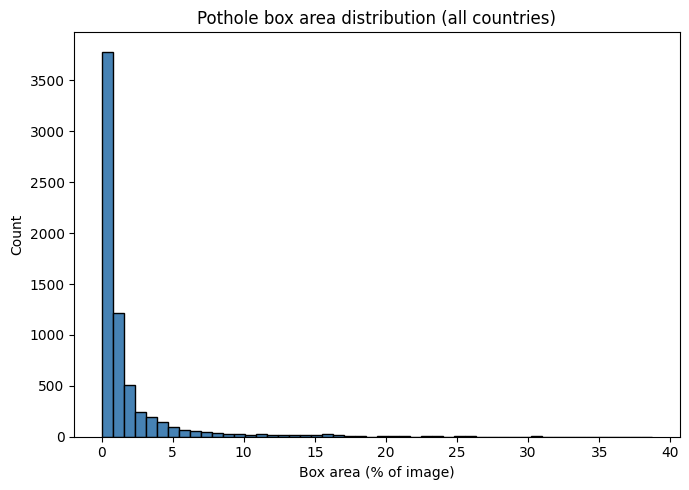

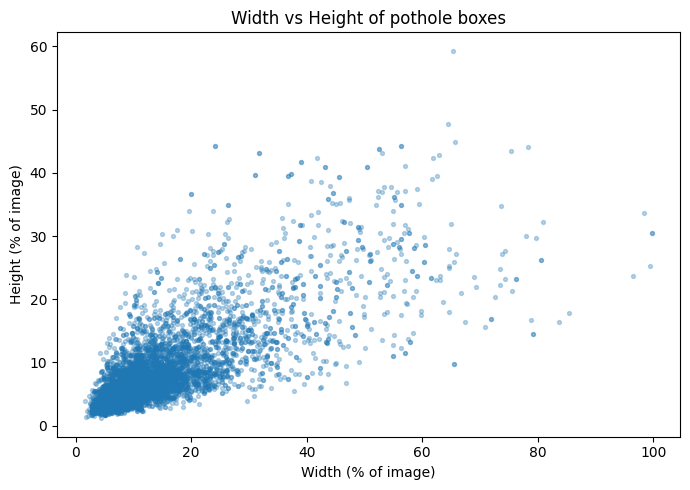

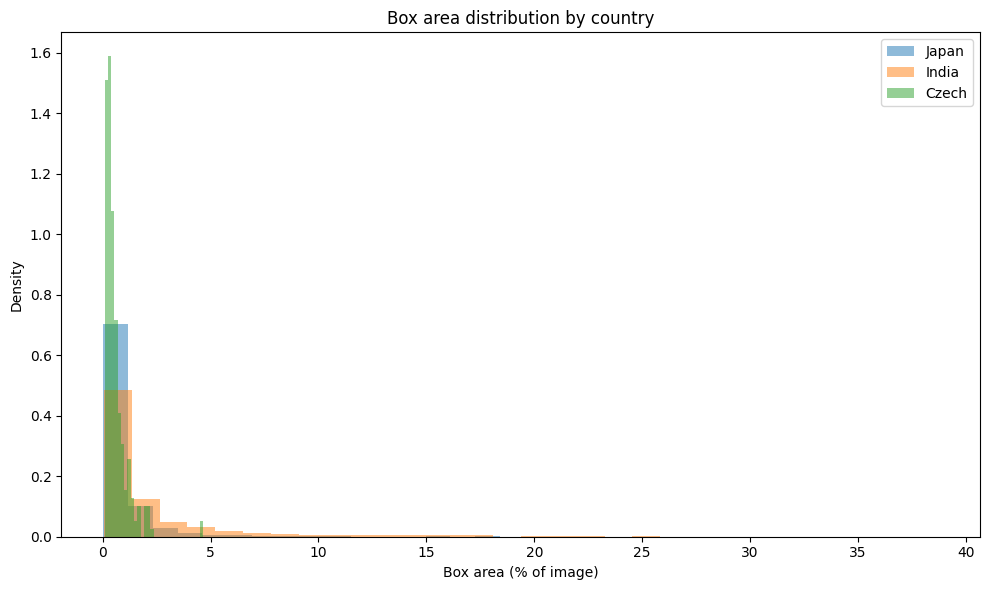

In [19]:
by_country =group_by_country(countries_list, areas)
print_country_breakdown(by_country)

# Each plot is now independent — call any one on its own
plot_area_histogram(areas)
plot_width_vs_height(widths, heights)
plot_area_by_country(by_country)

In [ ]:
from pathlib import Path

def polygon_to_bbox(parts):
    cls = parts[0]
    coords = list(map(float, parts[1:]))
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min
    return f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"

def fix_split(split):
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    fixed_count = 0
    total_converted = 0

    for f in lbl_dir.glob("Kenya_*.txt"):
        if f.stat().st_size == 0:
            continue
        lines = f.read_text().strip().split("\n")
        new_lines = []
        changed = False
        for line in lines:
            parts = line.split()
            if not parts:
                continue
            if len(parts) == 5:
                new_lines.append(line)
            elif len(parts) >= 7 and len(parts) % 2 == 1:
                new_lines.append(polygon_to_bbox(parts))
                changed = True
                total_converted += 1
        if changed:
            f.write_text("\n".join(new_lines))
            fixed_count += 1

    print(f"{split}: fixed {fixed_count} files, converted {total_converted} polygon lines to boxes")

fix_split("train")
fix_split("val")

train: fixed 132 files, converted 344 polygon lines to boxes
val: fixed 38 files, converted 99 polygon lines to boxes


In [ ]:
from pathlib import Path

for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    all_files = list(lbl_dir.glob("*.txt"))
    kenya_files = [f for f in all_files if "kenya" in f.name.lower()]
    print(f"{split}: {len(all_files)} total label files, {len(kenya_files)} contain 'kenya' (any case)")
    print("Sample filenames:", [f.name for f in all_files[:5]])

train: 6717 total label files, 183 contain 'kenya' (any case)
Sample filenames: ['India_India_000399.txt', 'Japan_Japan_008208.txt', 'India_India_005978.txt', 'Japan_Japan_003878.txt', 'Japan_Japan_010422.txt']
val: 1203 total label files, 52 contain 'kenya' (any case)
Sample filenames: ['India_India_006283.txt', 'Japan_Japan_006393.txt', 'Kenya_IMG_20241223_124948_jpg.rf.54069f822e2b46382d27833f0f763012.txt', 'India_India_000835.txt', 'Czech_Czech_002866.txt']


In [ ]:
from pathlib import Path

lbl_dir = Path("/content/rdd2020/final/train/labels")
kenya_files = [f for f in lbl_dir.glob("*.txt") if "kenya" in f.name.lower()]
print(kenya_files[:5])

[PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_132930_jpg.rf.ff655e11a27d906037b5e0d25d0222e3.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_132203_jpg.rf.5aef933190b50c53902c00e48db88cd5.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_134228_jpg.rf.873f39edb73aff776ea608a40620cc90.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125234_jpg.rf.8a2ca0367324e66c7bba7fa9b9d3b60a.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125459_jpg.rf.43d94f0d8f1876cb8ba3667388fd5259.txt')]


In [ ]:
from pathlib import Path

for split in ["train", "val"]:
    img_dir = Path(f"/content/rdd2020/final/{split}/images")
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")

    img_stems = {f.stem for f in img_dir.glob("*")}
    lbl_stems = {f.stem for f in lbl_dir.glob("*.txt")}

    missing_labels = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems

    print(f"{split}: {len(img_stems)} images, {len(lbl_stems)} labels")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Orphaned labels: {len(orphaned_labels)}")

train: 6717 images, 6717 labels
  Missing labels: 0
  Orphaned labels: 0
val: 1203 images, 1203 labels
  Missing labels: 0
  Orphaned labels: 0


In [ ]:
bad_files = []
for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    for f in lbl_dir.glob("*.txt"):
        with open(f) as fh:
            for i, line in enumerate(fh):
                parts = line.split()
                if len(parts) != 5:
                    bad_files.append((f, i, "wrong number of fields"))
                    continue
                cls, xc, yc, w, h = parts
                if int(cls) != 0:
                    bad_files.append((f, i, f"unexpected class id {cls}"))
                vals = [float(xc), float(yc), float(w), float(h)]
                if any(v < 0 or v > 1 for v in vals):
                    bad_files.append((f, i, "coordinate out of [0,1] range"))

print(f"Found {len(bad_files)} problematic label lines")
for f, i, reason in bad_files[:20]:
    print(f, i, reason)

Found 0 problematic label lines


In [ ]:
!cat "/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125459_jpg.rf.43d94f0d8f1876cb8ba3667388fd5259.txt"

0 0.456617646875 0.5569661453125 0.459068628125 0.556640625 0.459803921875 0.5537109375 0.4588235296875 0.5514322921875 0.4544117640625 0.5501302078125 0.4318627453125 0.548828125 0.40833333281249995 0.5524088546875 0.40857843125000004 0.5572916671875 0.4134803921875 0.5589192703125 0.439460784375 0.55859375 0.456617646875 0.5569661453125
0 0.5004901953124999 0.5250651046875 0.502696078125 0.5231119796875 0.5017156859375 0.5205078125 0.4977941171875 0.5201822921875 0.49411764687500004 0.5182291671875 0.4620098046875 0.5182291671875 0.448039215625 0.5211588546875 0.45171568593750006 0.5234375 0.46421568593750007 0.5244140625 0.4872549015625 0.5234375 0.5004901953124999 0.5250651046875
0 0.326225490625 0.5237630203125 0.3357843140625 0.5211588546875 0.334068628125 0.5182291671875 0.331617646875 0.517578125 0.31323529375 0.5182291671875 0.30392156875 0.5205078125 0.303431371875 0.521484375 0.3049019609375 0.5227864578125 0.3115196078125 0.5237630203125 0.326225490625 0.5237630203125
0 0.4

In [ ]:
from pathlib import Path

def is_valid_label_line(parts):
    if len(parts) == 5:
        return True  # standard box format
    if len(parts) >= 7 and len(parts) % 2 == 1:
        return True  # polygon format: class + even number of x,y pairs
    return False

bad_files = []
for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    for f in lbl_dir.glob("*.txt"):
        with open(f) as fh:
            for i, line in enumerate(fh):
                parts = line.split()
                if not parts:
                    continue
                if not is_valid_label_line(parts):
                    bad_files.append((f, i, f"{len(parts)} fields"))

print(f"Found {len(bad_files)} genuinely problematic label lines")
for f, i, reason in bad_files[:20]:
    print(f, i, reason)

Found 0 genuinely problematic label lines


In [ ]:
import hashlib

def file_hash(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

train_hashes = {file_hash(f): f for f in Path("/content/rdd2020/final/train/images").glob("*")}
val_hashes = {file_hash(f): f for f in Path("/content/rdd2020/final/val/images").glob("*")}

overlap = set(train_hashes) & set(val_hashes)
print(f"Duplicate images between train and val: {len(overlap)}")
for h in list(overlap)[:10]:
    print(train_hashes[h], val_hashes[h])

Duplicate images between train and val: 0


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=640,
    epochs=100,
    batch=-1,
    patience=25,
    seed=42,
    name="baseline_s_640",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_s_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783e759617c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

os.makedirs("/content/drive/MyDrive/potholes/runs", exist_ok=True)

# adjust source path to match what step 1 showed you
shutil.copytree(
    "/content/runs/detect/baseline_s_640/",   # your actual run folder
    "/content/drive/MyDrive/potholes/runs/train_backup",
    dirs_exist_ok=True
)

print("Copied to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive


In [ ]:
!find /content/runs -name "best.pt"

/content/runs/detect/baseline_s_640/weights/best.pt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = "/content/runs/detect/baseline_s_640/results.csv"
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()  # Ultralytics sometimes leaves leading spaces in column names

print(df.columns.tolist())  # confirm exact column names before plotting

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


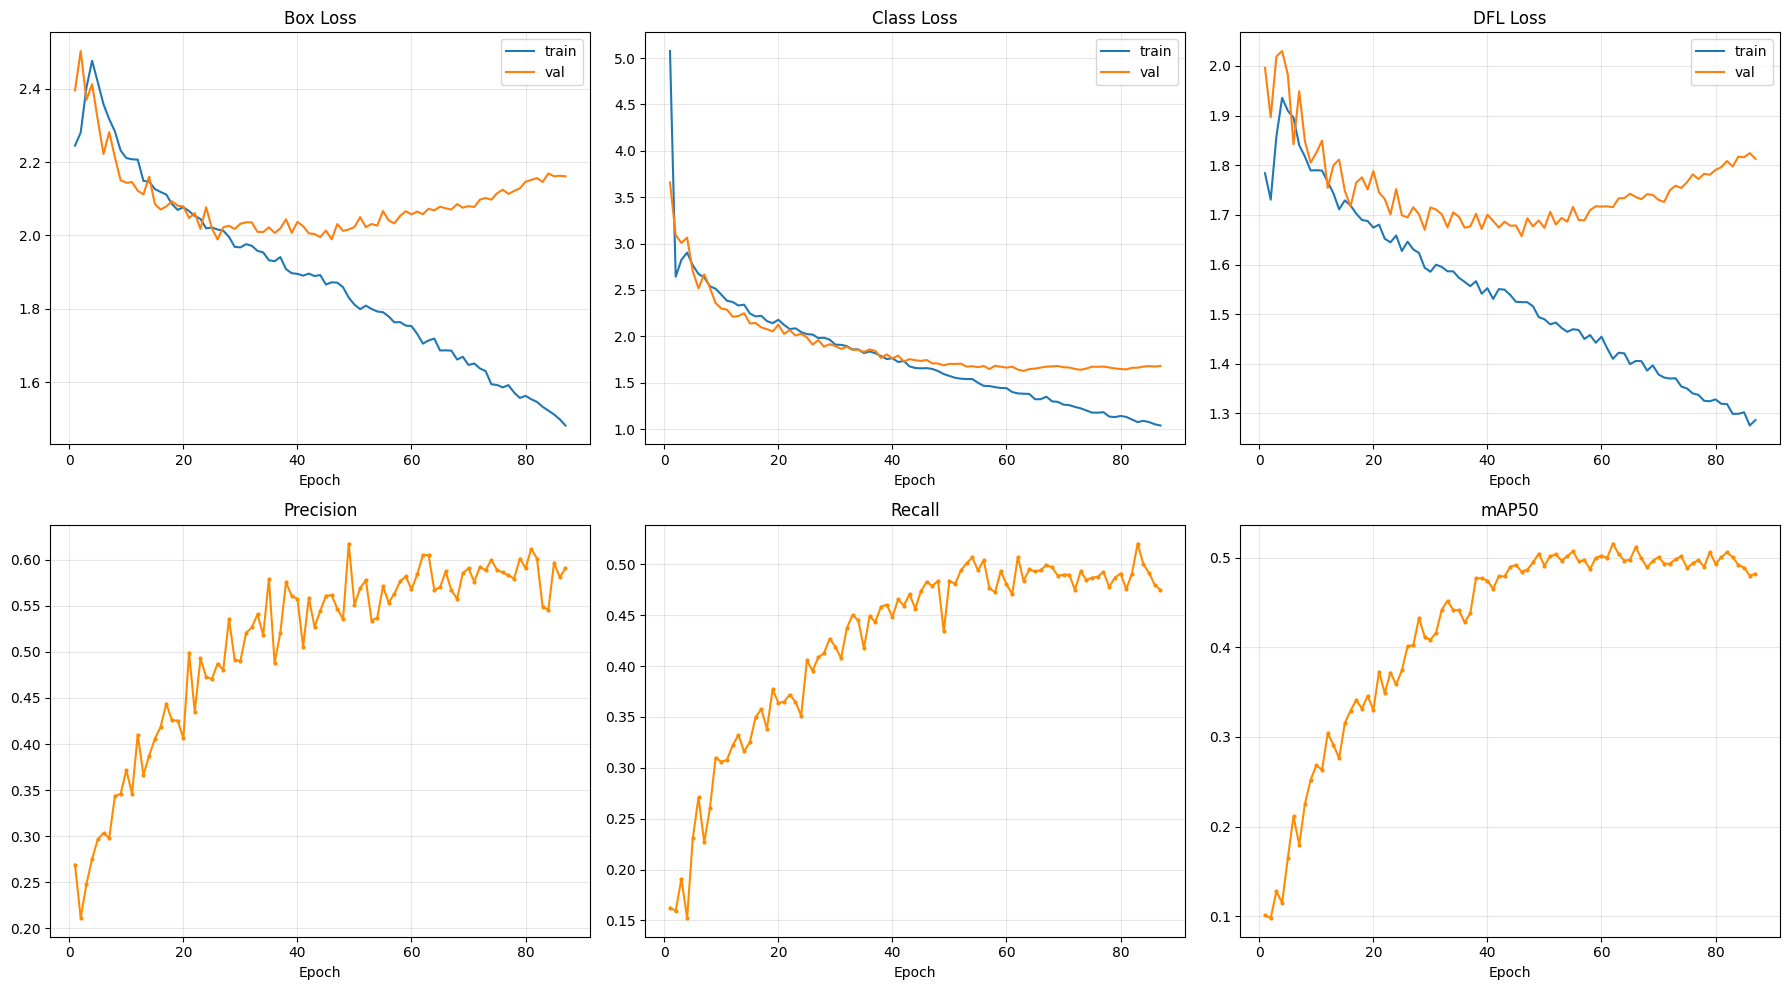

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: train vs val loss pairs
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes[0], loss_pairs):
    if train_col in df.columns and val_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train")
        ax.plot(df["epoch"], df[val_col], label="val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

# Row 2: precision, recall, mAP metrics
metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
]

for ax, (col, title) in zip(axes[1], metrics):
    if col in df.columns:
        ax.plot(df["epoch"], df[col], color="darkorange", marker='o', markersize=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/potholes/runs/s_960-2/weights/last.pt")
model.train(resume=True)

In [ ]:
model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=960,
    epochs=70,
    batch=-1,
    patience=20,
    seed=42,
    project="/content/drive/MyDrive/potholes/runs",  # saves here instead of /content/runs
    name="s_960",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s_960-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
model = YOLO("yolov8s.pt")
model.train(
    data="data.yaml",
    imgsz=960,
    epochs=100,
    batch=-1,              # auto-batch for available VRAM
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    box=9.0,
    scale=0.3,
    copy_paste=0.2,
    mosaic=0.6,
    close_mosaic=15,
    patience=25,
    seed=42,
)

NameError: name 'YOLO' is not defined

In [ ]:
#!pip install --quiet "numpy==1.26.4" "pandas==2.2.2" "ultralytics==8.2.103" "roboflow" 2>/dev/null
# Restart the Colab runtime automatically so the new Numpy takes effect

#import os
#os.kill(os.getpid(), 9)

#!pip uninstall -y numpy pandas
#!pip install numpy==1.26.4
#!pip install pandas==2.2.2
#!pip install ultralytics==8.2.103 -q

#!pip install roboflow
# Import common data science libraries
#import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from google.colab import userdata
from roboflow import Roboflow
import os
import glob
import random


# Import the Fynesse framework
#import fynesse
#from fynesse import access, assess, address

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.3 MB/s eta 0:00:00


In [ ]:

# @title fynesse(not currently used)
#### Cloning the Project Repository To utilize our custom Python modules and keep our project organized, we need to pull the latest version of our project repository into the Colab environment.The following cell performs a fresh clone by first removing any outdated versions of the folder, downloading the latest code from GitHub, and appending the repository to our system path so we can easily import our custom scripts.
# Remove existing repository folder to ensure a clean clone and setup
#import shutil
#shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

#!git clone https://github.com/silprosa/nipe_macho.git
#import os, subprocess, importlib, sys
#sys.path.append("/content/nipe_macho")

## 2. Initializing the YOLOv8 Base Model
Before we train the AI on our custom pothole dataset, we need to initialize a foundational model.

Instead of training a neural network completely from scratch—which requires massive amounts of time and data—we use **Transfer Learning**. In this cell, we load `yolov8n.pt` (the lightweight "Nano" version of YOLOv8), which has already been pre-trained on the massive COCO dataset. Because it already recognizes basic edges, shapes, and generic objects, it will learn to identify potholes much faster.


The Nano architecture was chosen specifically to balance high accuracy with fast, real-time inference speeds suitable for edge devices.

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 89.3MB/s]


A deeper dive into the YOLOv8 architecture and its capabilities can be found in the official [Ultralytics documentation](https://docs.ultralytics.com/models/yolov8#yolov8-usage-examples).

In [ ]:
model.info()

YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(225, 3157200, 0, 8.8575488)

---

## 3. Data Acquisition


Instead of hardcoding our private Roboflow API key directly into the notebook—which poses a severe security risk if the notebook is ever shared or committed to GitHub—we utilize Google Colab's built-in **Secrets** manager.

*To run this cell successfully, click the 🔑 Secrets icon on the left sidebar of Colab, add a new secret named `roboflow_api`, and paste your Roboflow API key as the value. Ensure the "Notebook access" toggle is turned on.*

In [ ]:
# safely retrieve our secret value
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "/content/data"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ziedkelboussi/rdd2020-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_597/2856089825.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


ValueError: Unsupported file extension: ''. Supported file extensions are: .csv, .tsv, .json, .jsonl, .xml, .parquet, .feather, .sqlite, .sqlite3, .db, .db3, .s3db, .dl3, .xls, .xlsx, .xlsm, .xlsb, .odf, .ods, .odt

### Fetching the Chepalungu Dataset
Using our authenticated Roboflow connection, we define our specific target directory. We navigate to the `nipemacho` workspace and select the `chepalungu` project.

The following cell downloads version 1 of our annotated pothole dataset into Colab, specifying 'yolov8' as the export format.
This formats the dataset and annotations into normalized text files compatible with YOLO architecture.

In [ ]:
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 5131.30it/s]


In [ ]:
print(dataset.location) # Prints the local directory where the dataset is downloaded

/content/chepalungu-1


## Phase 2: Assess (Dataset Verification)

During the annotation and export phase (via Roboflow), our dataset was automatically divided into three distinct splits: **train**, **valid** (validation), and **test**.

YOLO formats its annotations as `.txt` files containing normalized coordinates alongside these images. Before we begin training, we must perform a quick sanity check to ensure these folders were downloaded correctly and contain the expected number of images.

*(Note: We don't need to manually verify the bounding box coordinates or background images here, as the YOLOv8 training algorithm automatically performs a deep scan and summarizes dataset health before the first epoch begins).*

In [ ]:
import os

# Do a simple count of the files in the training folder
train_dir = f"{dataset.location}/train/images"
image_count = len(os.listdir(train_dir))

print(f"Found {image_count} images in the training folder.")

Found 183 images in the training folder.


## 4. Model Training

With our dataset verified and our hardware configured, we initiate the training sequence.

We are training the **YOLOv8s (Small)** architecture for 25 epochs. We have explicitly set the image size (`imgsz`) to 800 pixels (larger than the default 640) to preserve the resolution of smaller, distant road defects. Additionally, setting `plots=True` ensures the system automatically generates evaluation metrics, loss curves, and confusion matrices upon completion.

In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

100% 21.5M/21.5M [00:00<00:00, 209MB/s]
New https://pypi.org/project/ultralytics/8.4.82 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/chepalungu-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, reti

## 5. Model Evaluation

Once training is complete, we must evaluate the model's performance to ensure it has converged correctly and is not overfitting.


#### Locating the Model Weights and Results
When YOLOv8 completes a training run, it automatically generates a directory to save all outputs, including the finalized model weights (`best.pt`), evaluation charts, and validation predictions.

By default, Ultralytics structures this path as `runs/[task]/[mode]`. Since we performed object **detection** in **training** mode, our initial results are saved to `runs/detect/train`.

*(Note: If you run the training cell multiple times, YOLO will automatically create new folders sequentially, such as `train2`, `train3`, etc. to prevent overwriting your previous work. Ensure this path points to your most recent successful run).*

In [ ]:
# Define the results directory
results_dir = '/content/runs/detect/baseline_s_640'

YOLOv8 automatically generates comprehensive evaluation metrics during the training process. In the cell below, we extract and visualize:
1. **Training Metrics (`results.png`):** A graphical overview of the Loss curves, Precision, Recall, and mAP across all 25 epochs.


In [ ]:
# 1. Display results plot (loss and metrics over epochs)
results_plot = f'{results_dir}/results.png'

if os.path.exists(results_plot):
    print("--- Training Metrics ---")
    display(Image(filename=results_plot, width=800))
else:
    print("results.png not found in the specified directory.")

--- Training Metrics ---


NameError: name 'Image' is not defined

3. **Validation Batches:** Visual overlays of the model's predictions on the unseen validation dataset to physically confirm bounding box accuracy

In [ ]:
# 3. Display validation predictions
print("--- Validation Predictions ---")
found_images = False

for i in range(10):
    pred_path = f'{results_dir}/val_batch{i}_pred.jpg'
    if os.path.exists(pred_path):
        display(Image(filename=pred_path, width=800))
        found_images = True

if not found_images:
    print("No validation prediction batches (val_batchX_pred.jpg) found.")

--- Validation Predictions ---


NameError: name 'results_dir' is not defined

2. **Confusion Matrix (`confusion_matrix.png`):** To visualize the ratio of True Positives (correct detections) to False Positives (background mistakenly identified as a pothole).

In [ ]:
# 2. Display confusion matrix
confusion_matrix = f'{results_dir}/confusion_matrix.png'

if os.path.exists(confusion_matrix):
    print("--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix, width=600))
else:
    print("confusion_matrix.png not found in the specified directory.")

--- Confusion Matrix ---


NameError: name 'Image' is not defined

### Data Quality Visualization



---


## 6. Inference on Unseen Data

The ultimate test of an object detection model is its performance on data it has never seen before.

In this final section, we load our newly trained custom weights (`best.pt`) and run inference on the **Test** dataset. We set a confidence threshold of `0.25`, meaning the model will only draw a bounding box if it is at least 25% confident that the detected object is a pothole. Finally, we randomly sample and display the resulting images to visually verify the model's predictive accuracy.

In [ ]:


# 1. Load the newly trained custom weights
# (Using the latest_run variable from Section 5 ensures we get the right folder)
best_weights = os.path.join(results_dir, 'weights', 'best.pt')
model = YOLO(best_weights)

# 2. Define the path to the unseen test images using our dynamic variable
test_images_path = f"{dataset.location}/test/images"

# 3. Run inference!
# save=True generates the annotated images
# conf=0.25 sets the confidence threshold
print(f"Running predictions on: {test_images_path}")
results = model.predict(source=test_images_path, save=True, conf=0.25)

# 4. Display a few random predictions
# YOLO saves new predictions in a sequentially numbered 'predict' folder.
# We find the most recent one to ensure we are looking at the latest results.
predict_dirs = glob.glob('runs/detect/predict*')

if predict_dirs:
    latest_predict = max(predict_dirs, key=os.path.getmtime)
    predicted_images = glob.glob(f'{latest_predict}/*.jpg')

    if predicted_images:
        print(f"\n✅ --- Displaying Random Predictions from {latest_predict} ---")
        # Select up to 3 random images
        sample_images = random.sample(predicted_images, min(3, len(predicted_images)))
        for img_path in sample_images:
            display(Image(filename=img_path, width=800))
    else:
        print("No predicted images found inside the prediction folder.")
else:
    print("No prediction directory found. Check if model.predict() succeeded.")

Running predictions on: /content/chepalungu-1/test/images

image 1/26 /content/chepalungu-1/test/images/IMG_20241223_124318_jpg.rf.2a7165695765e7435a7d2a251f6ca041.jpg: 640x640 (no detections), 16.2ms
image 2/26 /content/chepalungu-1/test/images/IMG_20241223_124512_jpg.rf.3f09f5cf532a0931c69233607209b71a.jpg: 640x640 4 D40s, 16.2ms
image 3/26 /content/chepalungu-1/test/images/IMG_20241223_124730_jpg.rf.b6f73c67e54a4d33d39df0e232a5f95f.jpg: 640x640 1 D40, 16.2ms
image 4/26 /content/chepalungu-1/test/images/IMG_20241223_124732_jpg.rf.bfa5133b5972689508e32546759cbb22.jpg: 640x640 (no detections), 16.1ms
image 5/26 /content/chepalungu-1/test/images/IMG_20241223_124734_jpg.rf.f45e3c80d9a8513fd6edb1d4bf7d1b9b.jpg: 640x640 2 D40s, 16.1ms
image 6/26 /content/chepalungu-1/test/images/IMG_20241223_124927_jpg.rf.7533d31f3e831d06fd9b2dbae8b18e91.jpg: 640x640 1 D40, 16.2ms
image 7/26 /content/chepalungu-1/test/images/IMG_20241223_124953_jpg.rf.7a60a53cb3a4529454b9da650e7489bd.jpg: 640x640 (no detec

NameError: name 'glob' is not defined

### Analysis Results Visualization

---

## Next Steps: Customizing Your Analysis

### 1. Update Configuration
Edit `fynesse/defaults.yml` to point to your data sources:

### 2. Implement Your Data Access
Modify `fynesse/access.py` to load your specific data:

### 3. Add Data Assessment Logic
Enhance `fynesse/assess.py` with your quality checks:

### 4. Implement Analysis Functions
Customize `fynesse/address.py` for your specific questions: